<a href="https://colab.research.google.com/github/Harsh-GISMA/Data-science-Projects/blob/main/brain_tumors_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Introduction

Hello viewers, I am ***Harsh Deshmukh*** and my University no is ***GH1039479***. This project is created for applying Deep learning power to a deadly problem that anyone of us can face. Throughout this Pipeline we will cover all the important steps required to create an DL pipeline. But first lets understand the reason why I am creating this project.

##Understanding Business problem

In today's world everyone is concerned about their health, most of the people take great care of themselves while some prefer to not. But there are few health issues or disease that could not be avoided, tumors are one of those problems that we have not yet been able to tackle even if we have best health facilities. Brain tumors are among the most dangerous and life-threatening forms of cancer. Which can only be treated if we diagnosed it Early and accurately.  It is crucial for timely treatment and improved survival rates. However, manual diagnosis using MRI scans are time consuming and always poses chance of human error. This creates a critical gap in timely and consistent diagnosis, especially in developing countries or regions with limited medical infrastructure.

#Objectives

The goal of this project is straight and simple, using the power of Convolutional Neural Network (CNN) automatically classify brain tumors from MRI scans into four categories.  

* Glioma tumor
* Meningioma tumor
* Pituitary tumor
* No tumor
The perk of having DL model for this task is that, it can assist radiologists as a decision-support tool. Which farther can be deployed in clinics or mobile applications for real-time diagnosis. Reduce diagnosis time from hours to seconds.

So now that we have understood the problem and what we are supposed to do for it. Let's begin with project then

##Import all required libraries.

In [ ]:
import numpy as np
import pandas as pd
import shutil
import os
import keras
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, MaxPooling2D, Dropout, LeakyReLU
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization, LeakyReLU
from sklearn.metrics import accuracy_score
import ipywidgets as widgets
import io
from PIL import Image
import tqdm
from sklearn.model_selection import train_test_split
import cv2
from sklearn.utils import shuffle
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
warnings.filterwarnings('ignore')

#Data collection

Link to the dataset on kaggle - https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri

For this project I will use kaggle API to get the dataset, as it will be more easy to implement the model on any sever. plus it bypasses the need to download the data in my machine.

By this API request we will be getting 2 main folders Training and testing. In each of this 2 folders there are 4 additional folders named on the types of the tumor. There are total 3264 images divided in the folders.

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"harshdeshmukh1928","key":"2d020989c78c9f0ddedbfe8b1ce8bb80"}'}

Downloading required packages

In [ ]:
os.makedirs("/root/.kaggle", exist_ok=True)
shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 600)

In [ ]:
!kaggle datasets download -d sartajbhuvaji/brain-tumor-classification-mri

Dataset URL: https://www.kaggle.com/datasets/sartajbhuvaji/brain-tumor-classification-mri
License(s): MIT
  0% 0.00/86.8M [00:00<?, ?B/s]
100% 86.8M/86.8M [00:00<00:00, 1.39GB/s]


In [ ]:
!unzip brain-tumor-classification-mri.zip > /dev/null 2>&1

Now let's convert this images into pandas data frames

In [ ]:
X_train = []
Y_train = []
image_size = 150
labels = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']

for i in labels:
    folderPath = os.path.join('/content/Training', i)
    for j in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath, j))
        img = cv2.resize(img, (image_size, image_size))
        X_train.append(img)
        Y_train.append(i)

for i in labels:
    folderPath = os.path.join('/content/Testing', i)
    for j in os.listdir(folderPath):
        img = cv2.imread(os.path.join(folderPath, j))
        img = cv2.resize(img, (image_size, image_size))
        X_train.append(img)
        Y_train.append(i)

X_train = np.array(X_train)
Y_train = np.array(Y_train)

This is an random exaple of the images that we have.

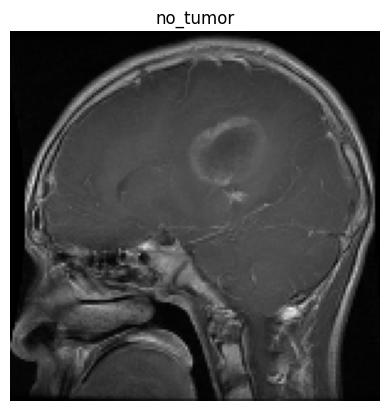

In [ ]:
plt.imshow(X_train[0])
plt.title(Y_train[0])
plt.axis('off')
plt.show()

#Data preprocessing

Now we will do some basic data preprocessing steps to ensure smooth running of our pipeline.

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


In [ ]:
X_train, Y_train = shuffle(X_train, Y_train, random_state=101)
print(X_train.shape)

(3264, 150, 150, 3)


In [ ]:
Y_train = Y_train[:X_train.shape[0]]

##Spliting the Data set in to train and test sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_train, Y_train, test_size=0.1, random_state=101)
print(X_train.shape, X_test.shape)

(2937, 150, 150, 3) (327, 150, 150, 3)


Let's take our string labels, converts them into integer indices based on the labels list, and then transforms those integers into a one-hot encoded format suitable for training deep learning model.

In [ ]:
y_train = y_train.tolist() if isinstance(y_train, np.ndarray) else y_train
y_test = y_test.tolist() if isinstance(y_test, np.ndarray) else y_test

y_train_new = []
for i in y_train:
    if i in labels:
        y_train_new.append(labels.index(i))
    else:
        y_train_new.append(-1)
y_train = np.array(y_train_new)
y_train = tf.keras.utils.to_categorical(y_train, num_classes=len(labels))

y_test_new = []
for i in y_test:
    if i in labels:
        y_test_new.append(labels.index(i))
    else:
        y_test_new.append(-1)
y_test = np.array(y_test_new)
y_test = tf.keras.utils.to_categorical(y_test, num_classes=len(labels))


## Image Normalization

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [ ]:
datagen.fit(X_train)

#Model training

In [ ]:
model = Sequential()
model.add(Conv2D(64, (3, 3), input_shape=(150, 150, 3)))
model.add(LeakyReLU(negative_slope=0.1))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(64, (3, 3)))
model.add(LeakyReLU(negative_slope=0.1))
model.add(Dropout(0.3))
model.add(Conv2D(64, (3, 3)))
model.add(LeakyReLU(negative_slope=0.1))
model.add(MaxPooling2D((2, 2)))

model.add(Conv2D(128, (3, 3)))
model.add(LeakyReLU(negative_slope=0.1))
model.add(Conv2D(128, (3, 3)))
model.add(LeakyReLU(negative_slope=0.1))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(128, (3, 3)))
model.add(LeakyReLU(negative_slope=0.1))
model.add(Conv2D(128, (3, 3)))
model.add(LeakyReLU(negative_slope=0.1))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))

model.add(Conv2D(256, (3, 3)))
model.add(LeakyReLU(negative_slope=0.1))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.3))

model.add(Flatten())
model.add(Dense(512,))
model.add(LeakyReLU(negative_slope=0.1))
model.add(Dense(512))
model.add(LeakyReLU(negative_slope=0.1))
model.add(Dropout(0.3))
model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


We will be  use different optimizer in this pipeline, but we will talk about it in later sections.

In [ ]:
optimizer = Adam(learning_rate=0.0005)
model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])

Early stopping to control our epochs

In [ ]:
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

And that's the main part fitting the model.

In [ ]:
history = model.fit(X_train, y_train, epochs=50, validation_split=0.1, callbacks=[early_stopping], batch_size=16)

Epoch 1/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.2843 - loss: 1.3742 - val_accuracy: 0.3197 - val_loss: 1.3238
Epoch 2/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.4385 - loss: 1.2103 - val_accuracy: 0.5952 - val_loss: 0.9558
Epoch 3/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.6082 - loss: 0.9707 - val_accuracy: 0.5578 - val_loss: 0.9986
Epoch 4/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.6355 - loss: 0.8626 - val_accuracy: 0.7449 - val_loss: 0.7432
Epoch 5/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.7554 - loss: 0.6361 - val_accuracy: 0.7823 - val_loss: 0.5517
Epoch 6/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7837 - loss: 0.5509 - val_accuracy: 0.7245 - val_loss: 0.6971
Epoch 7/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8360 - loss: 0.4313 - val_accuracy: 0.7891 - val_loss: 0.5487
Epoch 8/50
166/166 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8729 - loss: 0.3551 - val_acc

Let's see the accuracy score

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"\nFinal Test Accuracy: {accuracy:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.9353 - loss: 0.2877

Final Test Accuracy: 0.9327


##Now we will do some graphical representation of our model performance.

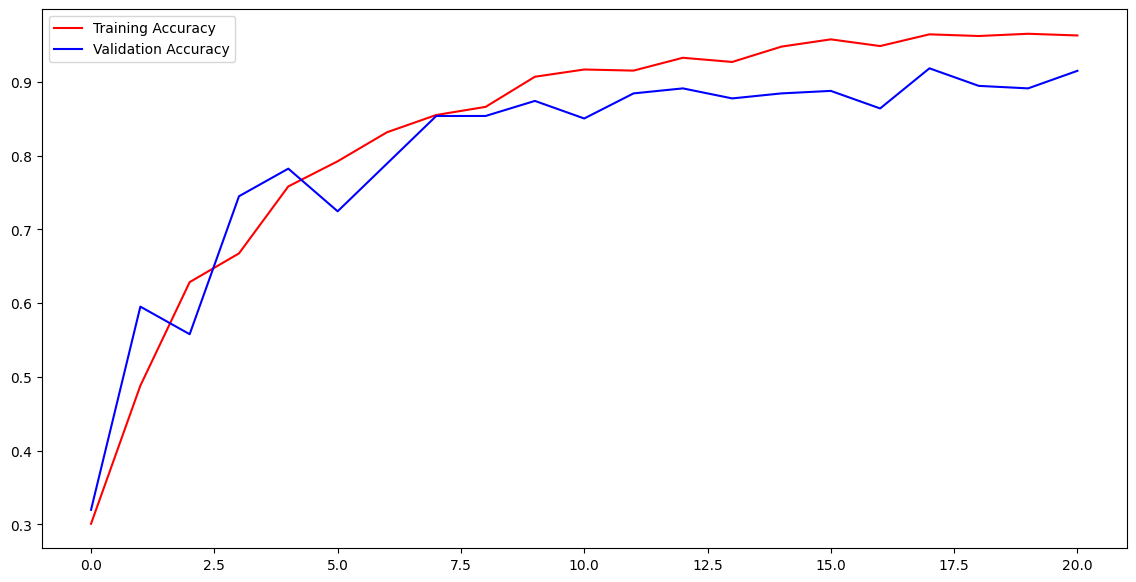

In [ ]:
model.save('braintumor.h5')

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs = range(len(acc))

fig = plt.figure(figsize=(14,7))
plt.plot(epochs, acc, 'r', label="Training Accuracy")
plt.plot(epochs, val_acc, 'b', label="Validation Accuracy")
plt.legend(loc='upper left')
plt.show()

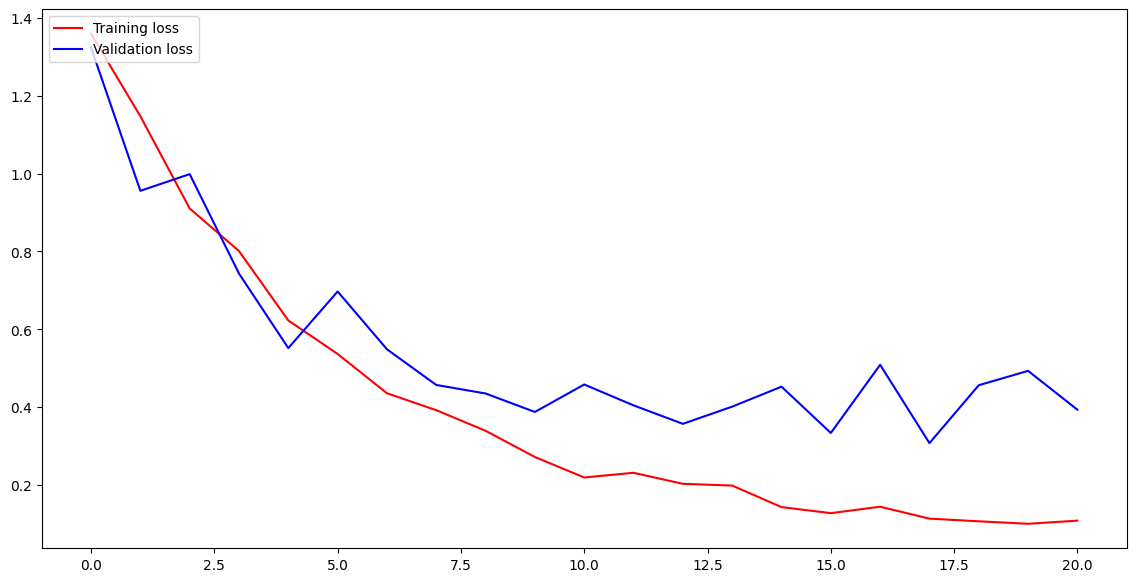

In [ ]:
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(loss))

fig = plt.figure(figsize=(14,7))
plt.plot(epochs, loss, 'r', label="Training loss")
plt.plot(epochs, val_loss, 'b', label="Validation loss")
plt.legend(loc='upper left')
plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 206ms/step


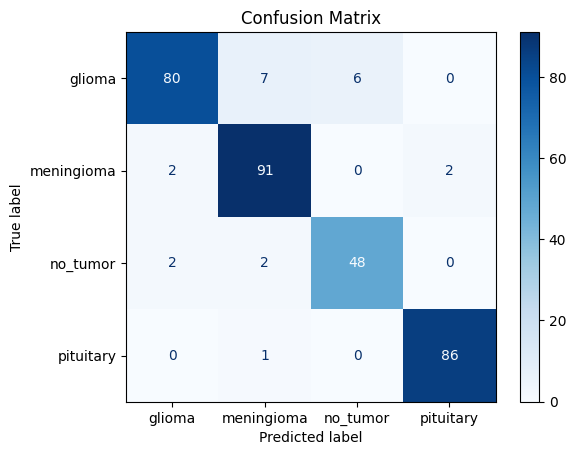

In [ ]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)
cm = confusion_matrix(y_true, y_pred_classes)
class_names = ['glioma', 'meningioma', 'no_tumor', 'pituitary']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Experiment section

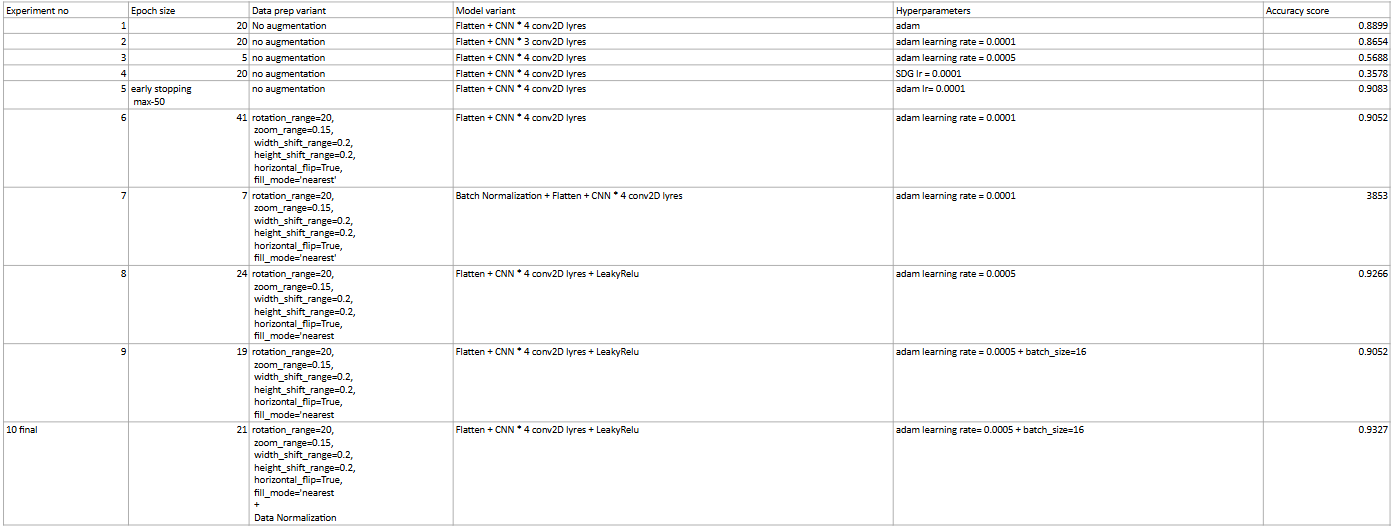

Above are the 10 experiments that have been conducted for this project. The existing code in the pipeline is the best version.

#Conclusion

This model addresses the real-world problem of  early and accurate brain tumor detection. It can be integrated into clinical decision support systems, especially in regions with limited access to expert radiologists. By reducing diagnostic time and minimizing human error, this system supports  faster and more reliable medical interventions.

The developed deep learning pipeline demonstrates that CNNs can achieve expert-level performance in brain tumor classification. With a validation accuracy of  93.27%, this model is well suited for real world deployment as a supportive tool in medical diagnostics.